In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import copy
import time
import torch
import numpy as np
from torch import nn
from matplotlib import pyplot as plt

# NOE

u shape: (35000,)
th shape: (35000,)


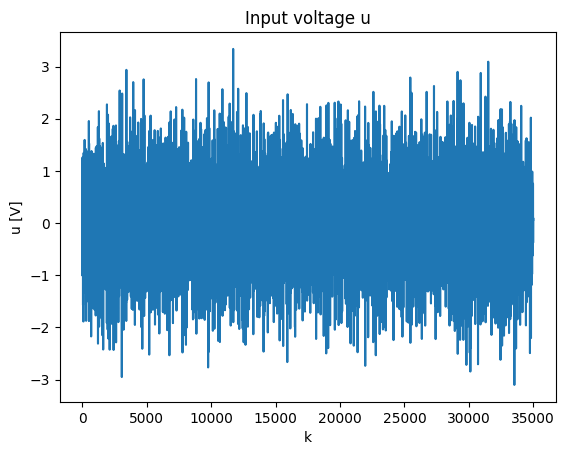

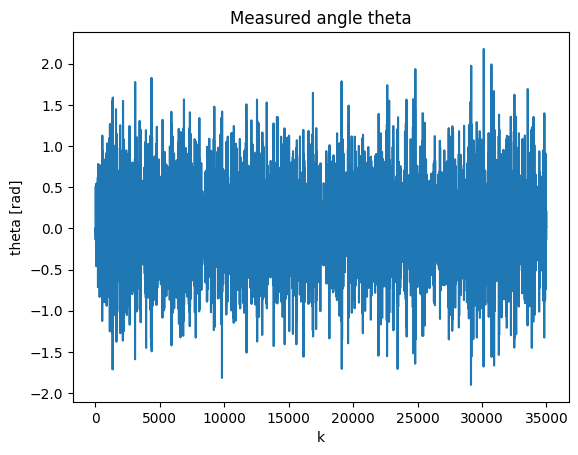

In [2]:
out = np.load("training-val-test-data.npz")

th = out["th"]   # measured disk angle
u = out["u"]     # applied input voltage

print("u shape:", u.shape)
print("th shape:", th.shape)

plt.figure()
plt.plot(u)
plt.title("Input voltage u")
plt.xlabel("k")
plt.ylabel("u [V]")
plt.show()

plt.figure()
plt.plot(th)
plt.title("Measured angle theta")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.show()

## Split into training - validation - test

 A block split was used instead of a random split because the data are time-series samples and neighboring points are correlated. This prevents data leakage between the training and validation/test sets.

In [3]:
N = len(u)

N_train = int(0.7 * N)
N_val = int(0.15 * N)

u_train = u[:N_train]
th_train = th[:N_train]

u_val = u[N_train:N_train + N_val]
th_val = th[N_train:N_train + N_val]

u_test = u[N_train + N_val:]
th_test = th[N_train + N_val:]

print(len(u_train), len(u_val), len(u_test))

24500 5250 5250


## Normalization 

The input voltage and measured angle were normalized to zero mean and unit variance before training. The normalization constants were computed only from the training set and then applied to the validation and test sets. This avoids data leakage and improves the conditioning of the neural network training problem.

In [4]:
u_mean = u_train.mean()
u_std = u_train.std()

th_mean = th_train.mean()
th_std = th_train.std()

u_train_n = (u_train - u_mean) / u_std
u_val_n = (u_val - u_mean) / u_std
u_test_n = (u_test - u_mean) / u_std

th_train_n = (th_train - th_mean) / th_std
th_val_n = (th_val - th_mean) / th_std
th_test_n = (th_test - th_mean) / th_std

print("u mean/std:", u_mean, u_std)
print("theta mean/std:", th_mean, th_std)

u mean/std: -2.687187240524085e-05 0.8410479397424789
theta mean/std: 0.03394048474666838 0.46785269160434234


## Construction of simulation windows

For NOE training, the time series was converted into overlapping input-output windows of length `nf = 100`. Each window contains a sequence of past input voltages and the corresponding measured output angles. These windows are used to train the model on short free-run simulation rollouts instead of only one-step-ahead samples.

In [5]:
def make_OE_data(udata, ydata, nf=100):
    U = [] 
    Y = [] 
    for k in range(nf, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])
    return np.array(U), np.array(Y)

## Choice of rollout horizon

A rollout horizon of `nf = 100` samples was used for training. This means that the NOE model is optimized to simulate output trajectories over short windows of 100 samples. The resulting training set contains 24,401 overlapping windows, while the validation set contains 5,151 windows.

In [6]:
nfuture = 100

U_train, Y_train = make_OE_data(u_train_n, th_train_n, nf=nfuture)
U_val, Y_val = make_OE_data(u_val_n, th_val_n, nf=nfuture)

print("U_train:", U_train.shape)
print("Y_train:", Y_train.shape)
print("U_val:", U_val.shape)
print("Y_val:", Y_val.shape)

U_train: (24401, 100)
Y_train: (24401, 100)
U_val: (5151, 100)
Y_val: (5151, 100)


## Conversion to PyTorch tensors

In [7]:
U_train_t = torch.tensor(U_train, dtype=torch.float64)
Y_train_t = torch.tensor(Y_train, dtype=torch.float64)

U_val_t = torch.tensor(U_val, dtype=torch.float64)
Y_val_t = torch.tensor(Y_val, dtype=torch.float64)

print(U_train_t.shape, Y_train_t.shape)

torch.Size([24401, 100]) torch.Size([24401, 100])


## NOE neural network structure

A nonlinear output-error (NOE) model was implemented using a feedforward neural network as the nonlinear mapping. At each time step, the network receives delayed input voltages and delayed model outputs as regressors

In [8]:
class NOENet(nn.Module):
    def __init__(self, na=5, nb=5, hidden_size=64):
        super().__init__()

        self.na = na
        self.nb = nb
        self.n0 = max(na, nb)

        input_size = na + nb

        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, hidden_size),
            nn.Tanh(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, U_seq, Y_seq):
        """
        U_seq: shape (batch, sequence_length)
        Y_seq: shape (batch, sequence_length)

        We use the first n0 true outputs only for initialization.
        After that, the model recursively feeds back its own predictions.
        """

        batch_size, seq_len = U_seq.shape

        # first n0 samples are used as initial conditions
        y_generated = []
        for i in range(self.n0):
            y_generated.append(Y_seq[:, i])

        # recursive simulation
        for t in range(self.n0, seq_len):
            u_lags = U_seq[:, t-self.nb:t]
            y_lags = torch.stack(y_generated[t-self.na:t], dim=1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = self.net(x).squeeze(1)
            y_generated.append(y_next)

        Y_hat = torch.stack(y_generated, dim=1)

        return Y_hat

## Mini-batch training data loader

The training windows were wrapped in a PyTorch `TensorDataset` and loaded using mini-batches of size 256. Shuffling was applied at the window level, not inside the sequences, so the temporal order within each rollout window is preserved while still enabling stochastic mini-batch optimization.

In [9]:
from torch.utils.data import TensorDataset, DataLoader

U_train_t = torch.tensor(U_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)

U_val_t = torch.tensor(U_val, dtype=torch.float32)
Y_val_t = torch.tensor(Y_val, dtype=torch.float32)

train_dataset = TensorDataset(U_train_t, Y_train_t)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

print(U_train_t.shape, Y_train_t.shape)

torch.Size([24401, 100]) torch.Size([24401, 100])


## NOE training procedure

The NOE model was trained by minimizing the mean squared simulation error over the rollout windows. The loss was computed only after the initialization period, since the first n0 samples are used as measured initial conditions and are not generated by the model. The Adam optimizer was used for parameter updates. Gradient clipping was applied to improve numerical stability during recursive simulation training. The model state with the lowest validation simulation loss was stored and restored after training.

In [10]:
def train_noe(model, train_loader, U_val_t, Y_val_t, epochs=100, lr=1e-3, weight_decay=1e-6):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.MSELoss()

    train_losses = []
    val_losses = []

    best_val_loss = np.inf
    best_state = None

    for epoch in range(epochs):
        model.train()
        batch_losses = []

        for U_batch, Y_batch in train_loader:
            optimizer.zero_grad()

            Y_hat = model(U_batch, Y_batch)

            # loss only after initialization part
            loss = loss_fn(Y_hat[:, model.n0:], Y_batch[:, model.n0:])

            loss.backward()

            # helps against exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()

            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)

        model.eval()
        with torch.no_grad():
            Y_val_hat = model(U_val_t, Y_val_t)
            val_loss = loss_fn(Y_val_hat[:, model.n0:], Y_val_t[:, model.n0:]).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

        if epoch % 10 == 0:
            print(f"Epoch {epoch:4d} | train sim loss = {train_loss:.6f} | val sim loss = {val_loss:.6f}")

    model.load_state_dict(best_state)

    return train_losses, val_losses

## NOE model training

The NOE model was trained with n_a=n_b=15, meaning that 15 delayed model outputs and 15 delayed input voltages were used as regressors. The nonlinear mapping was represented by a feedforward neural network with two hidden layers of 128 neurons. The model was trained using the Adam optimizer and mean squared simulation error. Weight decay was included as L_2-regularization to reduce overfitting and improve generalization.

In [25]:
na = 15
nb = 15
hidden_size = 128

model_noe = NOENet(na=na, nb=nb, hidden_size=hidden_size)

train_losses, val_losses = train_noe(
    model_noe,
    train_loader,
    U_val_t,
    Y_val_t,
    epochs=250,
    lr=1e-3,
    weight_decay=1e-6
)

Epoch    0 | train sim loss = 0.109545 | val sim loss = 0.080378
Epoch   10 | train sim loss = 0.005093 | val sim loss = 0.021417
Epoch   20 | train sim loss = 0.004838 | val sim loss = 0.013738
Epoch   30 | train sim loss = 0.003640 | val sim loss = 0.013939
Epoch   40 | train sim loss = 0.005015 | val sim loss = 0.013185
Epoch   50 | train sim loss = 0.002209 | val sim loss = 0.007644
Epoch   60 | train sim loss = 0.001951 | val sim loss = 0.008222
Epoch   70 | train sim loss = 0.002482 | val sim loss = 0.006189
Epoch   80 | train sim loss = 0.001666 | val sim loss = 0.009621
Epoch   90 | train sim loss = 0.001468 | val sim loss = 0.005323
Epoch  100 | train sim loss = 0.002037 | val sim loss = 0.005829
Epoch  110 | train sim loss = 0.002259 | val sim loss = 0.007023
Epoch  120 | train sim loss = 0.001403 | val sim loss = 0.005488
Epoch  130 | train sim loss = 0.001604 | val sim loss = 0.010857
Epoch  140 | train sim loss = 0.000855 | val sim loss = 0.003472
Epoch  150 | train sim lo

## Training and validation loss

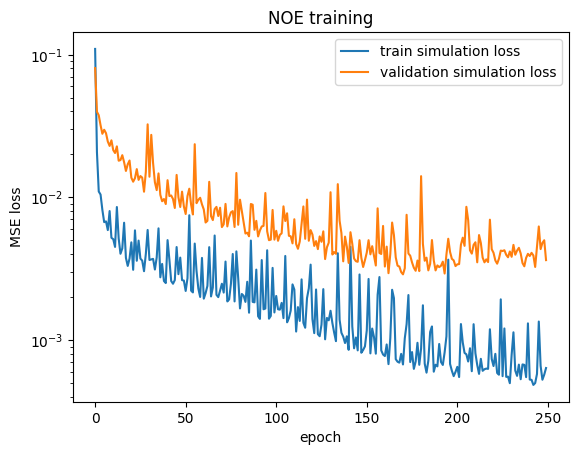

In [26]:
plt.figure()
plt.plot(train_losses, label="train simulation loss")
plt.plot(val_losses, label="validation simulation loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("MSE loss")
plt.title("NOE training")
plt.legend()
plt.show()

## Short-horizon validation rollout

A short validation rollout was performed on a single validation window of 100 samples. The first n_0=max(n_a,n_b) samples were used as initial conditions, after which the model recursively simulated the output using its own previous predictions. The predicted and measured angles were denormalized and compared in radians.


The short rollout performance was quantified using RMSE and normalized RMSE. The error was computed only after the initialization period, since the first n_0 samples are measured initial conditions and are not generated by the model.

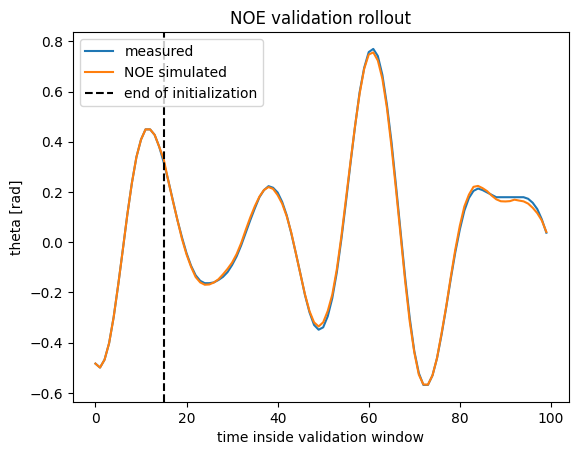

Validation rollout RMS: 0.010518653955011538 rad
Validation rollout RMS: 0.6026744777807524 deg
Validation rollout NRMS: 3.5466593653711618 %


In [27]:
model_noe.eval()

with torch.no_grad():
    Y_val_hat = model_noe(U_val_t[:1], Y_val_t[:1]).numpy()

Y_true = Y_val_t[:1].numpy()

# denormalize
Y_hat_denorm = Y_val_hat[0] * th_std + th_mean
Y_true_denorm = Y_true[0] * th_std + th_mean

plt.figure()
plt.plot(Y_true_denorm, label="measured")
plt.plot(Y_hat_denorm, label="NOE simulated")
plt.axvline(model_noe.n0, color="black", linestyle="--", label="end of initialization")
plt.xlabel("time inside validation window")
plt.ylabel("theta [rad]")
plt.title("NOE validation rollout")
plt.legend()
plt.show()

rms = np.sqrt(np.mean((Y_hat_denorm[model_noe.n0:] - Y_true_denorm[model_noe.n0:])**2))
nrms = rms / np.std(Y_true_denorm[model_noe.n0:])

print("Validation rollout RMS:", rms, "rad")
print("Validation rollout RMS:", rms / (2*np.pi) * 360, "deg")
print("Validation rollout NRMS:", nrms * 100, "%")

### Full free-run NOE simulation

A full free-run simulation function was implemented to evaluate the NOE model on an entire validation sequence. The first n_0=maxn_a,n_b measured output samples were used only for initialization. After that, the model recursively predicted the output and fed each prediction back as a delayed output for the next time step. This corresponds to the simulation behavior of a nonlinear output-error model.

In [28]:
def simulate_noe_full(model, u_seq, y_seq, th_mean, th_std):
    """
    Full free-run simulation for a normalized input sequence.

    u_seq: normalized input, shape (N,)
    y_seq: normalized measured output, shape (N,)
    """

    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    # initialize with true measured outputs
    y_generated = []

    for i in range(n0):
        y_generated.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            u_lags = u_t[t-nb:t].reshape(1, -1)
            y_lags = torch.stack(y_generated[t-na:t]).reshape(1, -1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = model.net(x).squeeze()
            y_generated.append(y_next)

    y_hat_n = torch.stack(y_generated).numpy()

    # denormalize
    y_hat = y_hat_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_hat, y_true

## Full validation simulation evaluation

The trained NOE model was evaluated on the full validation block in free-run simulation mode. The model was initialized with the first n_0 measured output samples and then simulated recursively using only the input sequence and its own previous predictions. The performance was evaluated using RMSE in radians, RMSE in degrees and normalized RMSE.

The full validation simulation was visualized by comparing the measured validation output with the simulated NOE output. In addition, the simulation residual was plotted to identify time intervals where the model error becomes larger. This helps assess whether the model errors are distributed uniformly or mainly occur during more aggressive transient motion.

Full validation simulation RMS: 0.03088334654153438 rad
Full validation simulation RMS: 1.7694854140698673 deg
Full validation simulation NRMS: 6.270887863321366 %


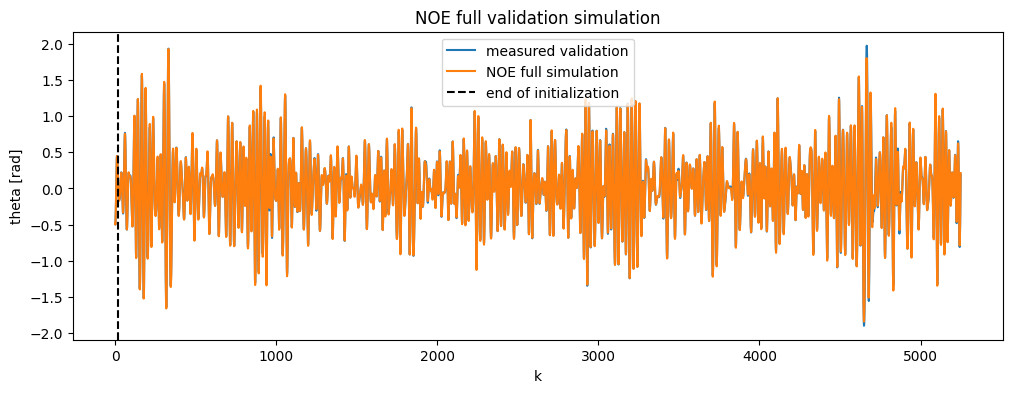

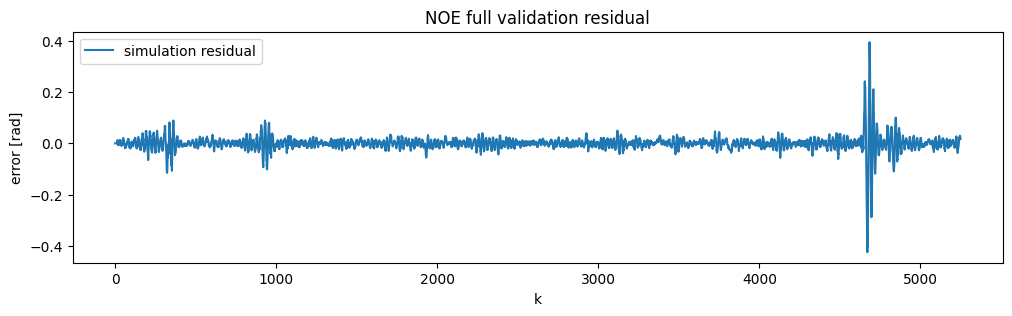

In [29]:
th_val_sim, th_val_true = simulate_noe_full(
    model_noe,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = model_noe.n0

rms = np.sqrt(np.mean((th_val_sim[skip:] - th_val_true[skip:])**2))
rms_deg = rms / (2*np.pi) * 360
nrms = rms / np.std(th_val_true[skip:])

print("Full validation simulation RMS:", rms, "rad")
print("Full validation simulation RMS:", rms_deg, "deg")
print("Full validation simulation NRMS:", nrms * 100, "%")

plt.figure(figsize=(12, 4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim, label="NOE full simulation")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("NOE full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_sim - th_val_true, label="simulation residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("NOE full validation residual")
plt.legend()
plt.show()

In [30]:
best_epoch = int(np.argmin(val_losses))
best_val_loss = np.min(val_losses)

print("Best epoch:", best_epoch)
print("Best validation simulation loss:", best_val_loss)

Best epoch: 170
Best validation simulation loss: 0.0028868329245597124


## NOE model tuning summary

The NOE model was tuned systematically by varying the delay orders, network size, learning rate, weight decay and number of training epochs. Increasing the delay orders from n_a=n_b=5 to n_a=n_b=15 significantly improved the long-horizon validation simulation performance, indicating that the model required a larger memory window to capture the system dynamics. Increasing the hidden layer size from 64 to 128 neurons further improved the nonlinear approximation capability of the network.

A smaller learning rate 5e^-4 and stronger weight decay 10^-5 were also tested, but both resulted in worse full validation simulation RMSE. Therefore, lr=10^-3 and weight decay 10^-6 were retained. Finally, the number of epochs was increased. The best performance was obtained with 250 epochs, resulting in a full validation simulation RMSE of 0.0309 rad, corresponding to 1.77 degrees and an NRMS of 6.27%.

Compared to the benchmark values provided in the repository, the final NOE model performs much better than the linear baseline and approaches the provided good NN simulation benchmark.

## One prediction test

In [31]:
def one_step_prediction_noe(model, u_seq, y_seq, th_mean, th_std):
    """
    One-step-ahead prediction for the NOE network.

    Here we use measured past outputs as regressors.
    This is different from simulation, where the model uses its own past predictions.
    """

    model.eval()

    u_t = torch.tensor(u_seq, dtype=torch.float32)
    y_t = torch.tensor(y_seq, dtype=torch.float32)

    N = len(u_t)
    n0 = model.n0
    na = model.na
    nb = model.nb

    y_pred = []

    # First n0 samples are copied only to keep the same length
    for i in range(n0):
        y_pred.append(y_t[i])

    with torch.no_grad():
        for t in range(n0, N):
            # measured past inputs
            u_lags = u_t[t-nb:t].reshape(1, -1)

            # measured past outputs, not predicted outputs
            y_lags = y_t[t-na:t].reshape(1, -1)

            x = torch.cat([u_lags, y_lags], dim=1)

            y_next = model.net(x).squeeze()
            y_pred.append(y_next)

    y_pred_n = torch.stack(y_pred).numpy()

    # denormalize
    y_pred_denorm = y_pred_n * th_std + th_mean
    y_true_denorm = y_seq * th_std + th_mean

    return y_pred_denorm, y_true_denorm

In [32]:
final_noe_model = model_noe   # change this to model_noe_250 if needed

th_val_pred, th_val_true_pred = one_step_prediction_noe(
    final_noe_model,
    u_val_n,
    th_val_n,
    th_mean,
    th_std
)

skip = final_noe_model.n0

pred_rms = np.sqrt(np.mean((th_val_pred[skip:] - th_val_true_pred[skip:])**2))
pred_rms_deg = pred_rms / (2*np.pi) * 360
pred_nrms = pred_rms / np.std(th_val_true_pred[skip:])

print("Validation one-step prediction RMS:", pred_rms, "rad")
print("Validation one-step prediction RMS:", pred_rms_deg, "deg")
print("Validation one-step prediction NRMS:", pred_nrms * 100, "%")

Validation one-step prediction RMS: 0.02494895450427764 rad
Validation one-step prediction RMS: 1.429469796359014 deg
Validation one-step prediction NRMS: 5.065904881552339 %


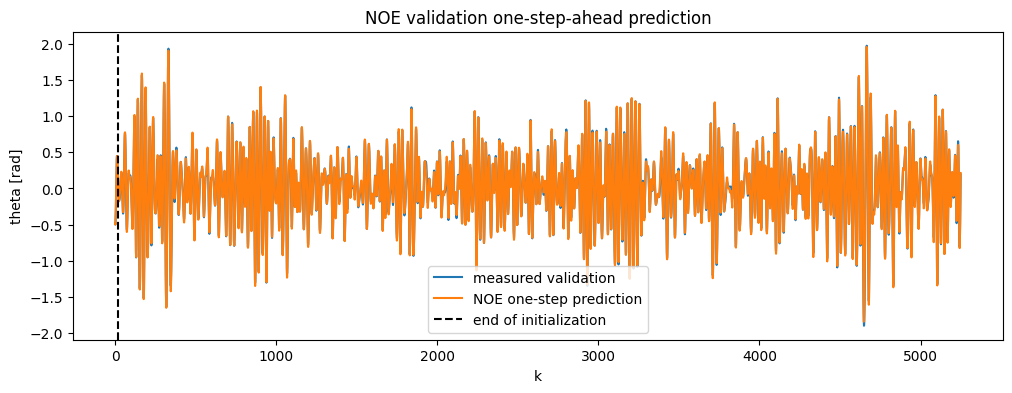

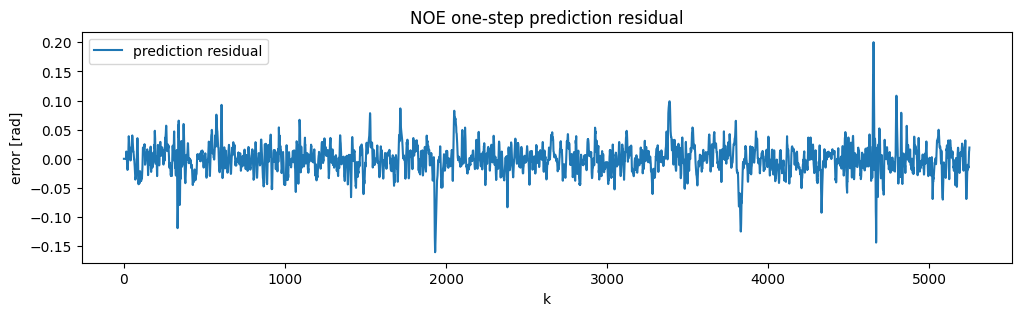

In [33]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_pred, label="measured validation")
plt.plot(th_val_pred, label="NOE one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="end of initialization")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("NOE validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred - th_val_true_pred, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("NOE one-step prediction residual")
plt.legend()
plt.show()

## One-step-ahead prediction evaluation

The final NOE model was also evaluated in one-step-ahead prediction mode. In contrast to free-run simulation, the measured past outputs were used as regressors at every time step. This makes the task easier than simulation, since prediction errors are not recursively fed back into the model. The resulting prediction performance was evaluated using RMSE, RMSE in degrees and NRMS.

The final NOE model was also evaluated in one-step-ahead prediction mode. In this case, measured past outputs were used as regressors at every time step, instead of recursively feeding back the model predictions. This makes one-step prediction easier than free-run simulation, because prediction errors do not accumulate over time and also excuses why have better results than simulation.

The final NOE model achieved a validation one-step prediction RMSE of 0.02495 rad, corresponding to 1.43 degrees and an NRMS of 5.07%. As expected, this is lower than the full simulation RMSE of 0.03088 rad. However, the prediction performance is not as strong as the provided good NN prediction benchmark, since the NOE model was mainly trained using simulation error rather than a pure one-step prediction objective.

# RNN

## RNN sequence data

For the RNN model, the normalized input-output time series was converted into overlapping sequences of length `nfuture_rnn`. This follows the sequence construction used in the lecture exercise. Each training sample contains an input voltage sequence and the corresponding measured angle sequence.

In [10]:
nfuture_rnn = 100

U_train_rnn, Y_train_rnn = make_OE_data(u_train_n, th_train_n, nf=nfuture_rnn)
U_val_rnn, Y_val_rnn = make_OE_data(u_val_n, th_val_n, nf=nfuture_rnn)

U_train_rnn_t = torch.tensor(U_train_rnn, dtype=torch.float64)
Y_train_rnn_t = torch.tensor(Y_train_rnn, dtype=torch.float64)

U_val_rnn_t = torch.tensor(U_val_rnn, dtype=torch.float64)
Y_val_rnn_t = torch.tensor(Y_val_rnn, dtype=torch.float64)

print(U_train_rnn_t.shape, Y_train_rnn_t.shape)
print(U_val_rnn_t.shape, Y_val_rnn_t.shape)

torch.Size([24401, 100]) torch.Size([24401, 100])
torch.Size([5151, 100]) torch.Size([5151, 100])


## Simple RNN model

The RNN model follows the structure used in the lecture exercise. It consists of two neural networks: `h2h`, which updates the hidden state, and `h2o`, which maps the current hidden state and input to the output. The model equations are

h_{k+1} = \text{h2h}(h_k,u_k),

hat{\theta}_k = \text{h2o}(h_k,u_k).

The hidden state is initialized to zero at the start of each sequence.

In [11]:
class simple_RNN(nn.Module):
    def __init__(self, hidden_size):
        super(simple_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.hidden_size + self.input_size, self.hidden_size)
        self.h2o = net(self.hidden_size + self.input_size, self.output_size)

    def forward(self, inputs):
        # inputs shape = (N_batch, N_time)

        N_batch = inputs.shape[0]
        N_time = inputs.shape[1]

        hidden = torch.zeros(
            N_batch,
            self.hidden_size,
            dtype=torch.float64
        )

        outputs = []

        for k in range(N_time):
            uk = inputs[:, k:k+1]

            h_and_u = torch.cat((hidden, uk), dim=1)

            yk = self.h2o(h_and_u)[:, 0]

            hidden = self.h2h(h_and_u)

            outputs.append(yk)

        outputs = torch.stack(outputs, dim=1)

        return outputs

## RNN training

The RNN was trained using mini-batch optimization with the Adam optimizer, following the lecture exercise. The loss was computed after a burn-in period of `n_burn` samples, because the hidden state is initialized at zero and needs a few samples to encode information about the system state. The training and validation losses are reported as normalized sequence RMSE values.

In [12]:
n_burn = 15
batch_size = 64
hidden_size = 15
epochs = 50

model_rnn = simple_RNN(hidden_size=hidden_size)
optimizer = torch.optim.Adam(model_rnn.parameters(), lr=1e-3)

train_losses_rnn = []
val_losses_rnn = []

ids = np.arange(len(U_train_rnn_t), dtype=int)

for epoch in range(epochs):
    np.random.shuffle(ids)

    for i in range(0, len(U_train_rnn_t), batch_size):
        ids_now = ids[i:i+batch_size]

        U_batch = U_train_rnn_t[ids_now]
        Y_batch = Y_train_rnn_t[ids_now]

        Y_pred = model_rnn(inputs=U_batch)

        loss = torch.mean((Y_pred[:, n_burn:] - Y_batch[:, n_burn:])**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        train_loss = torch.mean((model_rnn(inputs=U_train_rnn_t)[:, n_burn:] - Y_train_rnn_t[:, n_burn:])**2).sqrt()
        val_loss = torch.mean((model_rnn(inputs=U_val_rnn_t)[:, n_burn:] - Y_val_rnn_t[:, n_burn:])**2).sqrt()

    train_losses_rnn.append(train_loss.item())
    val_losses_rnn.append(val_loss.item())

    print(f"epoch={epoch}, Validation Loss={val_loss.item():.2%}, Train Loss={train_loss.item():.2%}")

epoch=0, Validation Loss=86.29%, Train Loss=81.47%
epoch=1, Validation Loss=54.90%, Train Loss=49.11%
epoch=2, Validation Loss=50.28%, Train Loss=43.60%
epoch=3, Validation Loss=49.43%, Train Loss=42.28%
epoch=4, Validation Loss=51.10%, Train Loss=43.75%
epoch=5, Validation Loss=48.88%, Train Loss=41.64%
epoch=6, Validation Loss=49.08%, Train Loss=41.56%
epoch=7, Validation Loss=48.88%, Train Loss=41.37%
epoch=8, Validation Loss=48.91%, Train Loss=42.06%
epoch=9, Validation Loss=48.70%, Train Loss=41.53%
epoch=10, Validation Loss=49.22%, Train Loss=41.45%
epoch=11, Validation Loss=50.94%, Train Loss=43.67%
epoch=12, Validation Loss=49.97%, Train Loss=42.94%
epoch=13, Validation Loss=48.75%, Train Loss=41.49%
epoch=14, Validation Loss=49.30%, Train Loss=41.54%
epoch=15, Validation Loss=48.17%, Train Loss=41.42%
epoch=16, Validation Loss=48.31%, Train Loss=41.17%
epoch=17, Validation Loss=49.40%, Train Loss=42.41%
epoch=18, Validation Loss=49.34%, Train Loss=41.66%
epoch=19, Validation L

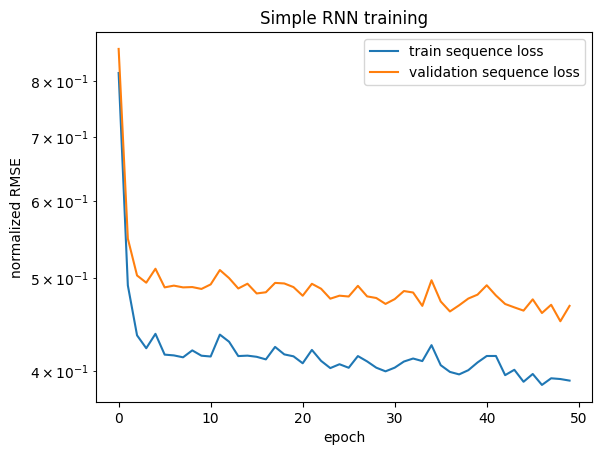

In [13]:
plt.figure()
plt.plot(train_losses_rnn, label="train sequence loss")
plt.plot(val_losses_rnn, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Simple RNN training")
plt.legend()
plt.show()

## Full validation simulation with the RNN

The trained RNN was evaluated on the full validation input sequence. The hidden state was initialized to zero and then updated recursively using the input sequence. The first `n_burn` samples were skipped when computing the RMSE, because they correspond to the initial transient of the hidden state. The simulated output was compared with the measured validation angle.

RNN full validation simulation RMS: 0.14364393502652292 rad
RNN full validation simulation RMS: 8.23019122967118 deg
RNN full validation simulation NRMS: 29.167014254304064 %


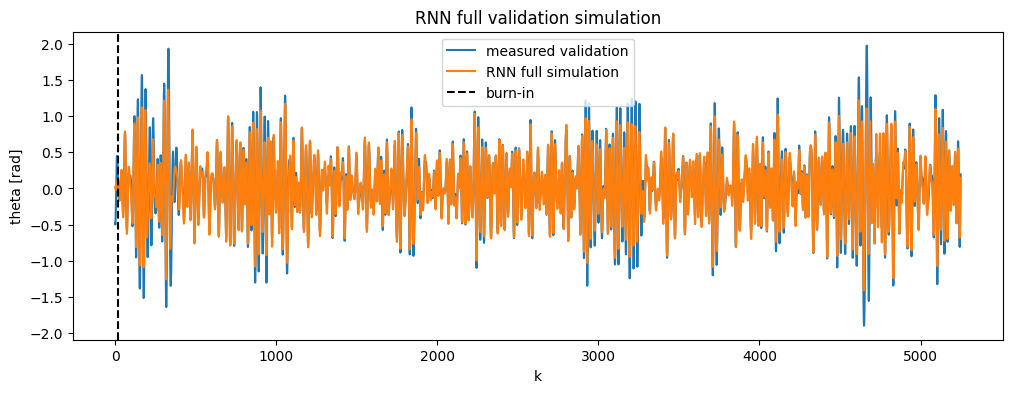

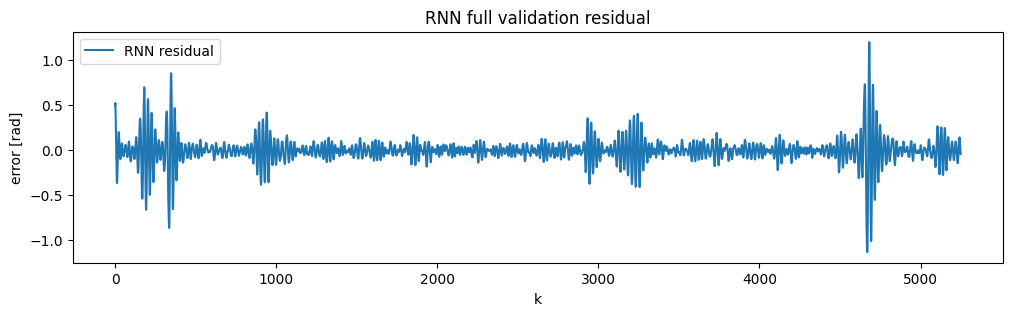

In [14]:
model_rnn.eval()

with torch.no_grad():
    U_val_full_t = torch.tensor(u_val_n[None, :], dtype=torch.float64)
    th_val_sim_rnn_n = model_rnn(U_val_full_t).numpy()[0]

th_val_sim_rnn = th_val_sim_rnn_n * th_std + th_mean
th_val_true = th_val_n * th_std + th_mean

skip = n_burn

rms_rnn = np.sqrt(np.mean((th_val_sim_rnn[skip:] - th_val_true[skip:])**2))
rms_deg_rnn = rms_rnn / (2*np.pi) * 360
nrms_rnn = rms_rnn / np.std(th_val_true[skip:])

print("RNN full validation simulation RMS:", rms_rnn, "rad")
print("RNN full validation simulation RMS:", rms_deg_rnn, "deg")
print("RNN full validation simulation NRMS:", nrms_rnn * 100, "%")

plt.figure(figsize=(12,4))
plt.plot(th_val_true, label="measured validation")
plt.plot(th_val_sim_rnn, label="RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="burn-in")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(th_val_sim_rnn - th_val_true, label="RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("RNN full validation residual")
plt.legend()
plt.show()

## Encoder RNN sequence data

For the encoder RNN, each training sample contains three parts: a future input sequence \(U_k\), the corresponding output sequence \(Y_k\), and a history vector containing past inputs and past outputs. The history vector is used by the encoder network to estimate the initial hidden state of the RNN.

In [15]:
def make_OE_init_state_data(udata, ydata, nf=100, n_encode=20):
    U = [] 
    Y = [] 
    hist = [] 

    for k in range(nf + n_encode, len(udata) + 1):
        U.append(udata[k-nf:k])
        Y.append(ydata[k-nf:k])

        u_past = udata[k-nf-n_encode:k-nf]
        y_past = ydata[k-nf-n_encode:k-nf]

        hist.append(np.concatenate((u_past, y_past)))

    return np.array(hist), np.array(U), np.array(Y)

## Encoder history length

The encoder history length was set to \(n_e=20\). Therefore, the encoder input contains 20 past input samples and 20 past output samples. This provides the RNN with information about the initial state before the simulated sequence starts.

In [69]:
nfuture_rnn = 100
n_encode = 50

convert = lambda x: [torch.tensor(xi, dtype=torch.float64) for xi in x]

hist_train_rnn, U_train_rnn, Y_train_rnn = convert(
    make_OE_init_state_data(
        u_train_n,
        th_train_n,
        nf=nfuture_rnn,
        n_encode=n_encode
    )
)

hist_val_rnn, U_val_rnn, Y_val_rnn = convert(
    make_OE_init_state_data(
        u_val_n,
        th_val_n,
        nf=nfuture_rnn,
        n_encode=n_encode
    )
)

print("hist_train:", hist_train_rnn.shape)
print("U_train:", U_train_rnn.shape)
print("Y_train:", Y_train_rnn.shape)

print("hist_val:", hist_val_rnn.shape)
print("U_val:", U_val_rnn.shape)
print("Y_val:", Y_val_rnn.shape)

hist_train: torch.Size([24351, 100])
U_train: torch.Size([24351, 100])
Y_train: torch.Size([24351, 100])
hist_val: torch.Size([5101, 100])
U_val: torch.Size([5101, 100])
Y_val: torch.Size([5101, 100])


## Encoder RNN model

In [70]:
class simple_encoder_RNN(nn.Module):
    def __init__(self, hidden_size, n_encoder=20):
        super(simple_encoder_RNN, self).__init__()

        self.hidden_size = hidden_size
        self.input_size = 1
        self.output_size = 1
        self.n_encoder = n_encoder

        net = lambda n_in, n_out: nn.Sequential(
            nn.Linear(n_in, 40),
            nn.Sigmoid(),
            nn.Linear(40, n_out)
        ).double()

        self.h2h = net(self.input_size + hidden_size, self.hidden_size)
        self.h2o = net(self.input_size + hidden_size, self.output_size)
        self.encoder = net(n_encoder * 2, hidden_size)

    def forward(self, inputs, hist):
        hidden = self.encoder(hist)

        outputs = []

        for i in range(inputs.shape[1]):
            input_i = inputs[:, i]
            combined = torch.cat((hidden, input_i[:, None]), dim=1)

            outputs.append(self.h2o(combined)[:, 0])

            hidden = self.h2h(combined)

        return torch.stack(outputs, dim=1)

## Encoder RNN training

The encoder RNN was trained using the Adam optimizer and mean squared sequence error. In contrast to the simple RNN, no burn-in period is required, because the initial hidden state is estimated directly from the past input-output history using the encoder network.

In [79]:
hidden_size = 30
batch_size = 64
epochs = 50

model_encoder_rnn = simple_encoder_RNN(
    hidden_size=hidden_size,
    n_encoder=n_encode
)

optimizer = torch.optim.Adam(model_encoder_rnn.parameters(), lr=1e-3)

train_losses_encoder_rnn = []
val_losses_encoder_rnn = []

ids = np.arange(len(U_train_rnn), dtype=int)

for epoch in range(epochs):
    np.random.shuffle(ids)

    for i in range(0, len(U_train_rnn), batch_size):
        ids_now = ids[i:i+batch_size]

        Uin = U_train_rnn[ids_now]
        histin = hist_train_rnn[ids_now]
        Y_real = Y_train_rnn[ids_now]

        Y_predict = model_encoder_rnn(inputs=Uin, hist=histin)

        residual = Y_real - Y_predict
        loss = torch.mean(residual**2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    with torch.no_grad():
        Y_val_pred = model_encoder_rnn(inputs=U_val_rnn, hist=hist_val_rnn)
        Y_train_pred = model_encoder_rnn(inputs=U_train_rnn, hist=hist_train_rnn)

        loss_val = torch.mean((Y_val_pred - Y_val_rnn)**2)**0.5
        loss_train = torch.mean((Y_train_pred - Y_train_rnn)**2)**0.5

    train_losses_encoder_rnn.append(loss_train.item())
    val_losses_encoder_rnn.append(loss_val.item())

    print(f"epoch={epoch}, Validation Loss={loss_val.item():.2%}, Train Loss={loss_train.item():.2%}")

epoch=0, Validation Loss=52.97%, Train Loss=47.21%
epoch=1, Validation Loss=37.00%, Train Loss=29.89%
epoch=2, Validation Loss=35.63%, Train Loss=28.12%
epoch=3, Validation Loss=34.58%, Train Loss=27.01%
epoch=4, Validation Loss=34.81%, Train Loss=27.66%
epoch=5, Validation Loss=33.79%, Train Loss=25.67%
epoch=6, Validation Loss=33.06%, Train Loss=25.50%
epoch=7, Validation Loss=32.66%, Train Loss=25.10%
epoch=8, Validation Loss=31.58%, Train Loss=24.07%
epoch=9, Validation Loss=29.53%, Train Loss=22.87%
epoch=10, Validation Loss=29.64%, Train Loss=23.28%
epoch=11, Validation Loss=25.47%, Train Loss=19.22%
epoch=12, Validation Loss=21.82%, Train Loss=17.24%
epoch=13, Validation Loss=23.92%, Train Loss=18.86%
epoch=14, Validation Loss=15.73%, Train Loss=11.04%
epoch=15, Validation Loss=15.85%, Train Loss=10.79%
epoch=16, Validation Loss=16.11%, Train Loss=10.60%
epoch=17, Validation Loss=15.54%, Train Loss=9.41%
epoch=18, Validation Loss=15.52%, Train Loss=9.88%
epoch=19, Validation Los

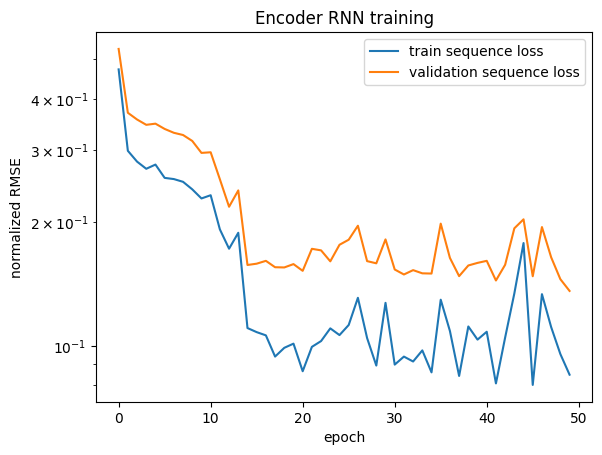

In [80]:
plt.figure()
plt.plot(train_losses_encoder_rnn, label="train sequence loss")
plt.plot(val_losses_encoder_rnn, label="validation sequence loss")
plt.yscale("log")
plt.xlabel("epoch")
plt.ylabel("normalized RMSE")
plt.title("Encoder RNN training")
plt.legend()
plt.show()

### Full validation simulation with encoder RNN

For the full validation simulation, the first \(n_e\) measured input-output samples were used as encoder history to estimate the initial hidden state. After this initialization, the RNN simulated the remaining validation sequence using only the input signal and the recurrent hidden state dynamics.

In [81]:
def simulate_encoder_rnn_full(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    Full validation simulation for encoder RNN.

    Uses the first n_encode input-output samples as history to initialize hidden state.
    Then simulates the rest of the sequence.
    """

    model.eval()

    u_hist = u_seq[:n_encode]
    y_hist = y_seq[:n_encode]

    hist = np.concatenate((u_hist, y_hist))[None, :]
    u_future = u_seq[n_encode:][None, :]

    hist_t = torch.tensor(hist, dtype=torch.float64)
    u_future_t = torch.tensor(u_future, dtype=torch.float64)

    with torch.no_grad():
        y_future_pred_n = model(inputs=u_future_t, hist=hist_t).numpy()[0]

    y_pred_n = np.concatenate((y_seq[:n_encode], y_future_pred_n))

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

Encoder RNN full validation simulation RMS: 0.06965051042509074 rad
Encoder RNN full validation simulation RMS: 3.990680288289641 deg
Encoder RNN full validation simulation NRMS: 14.101367265089554 %


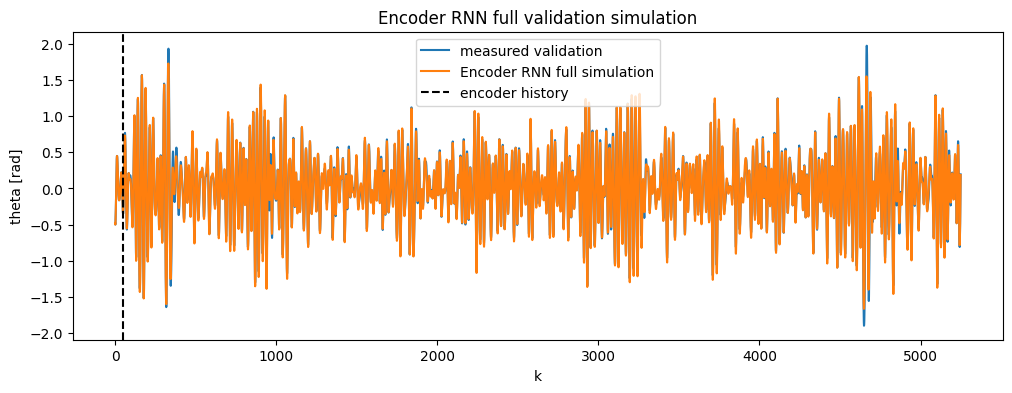

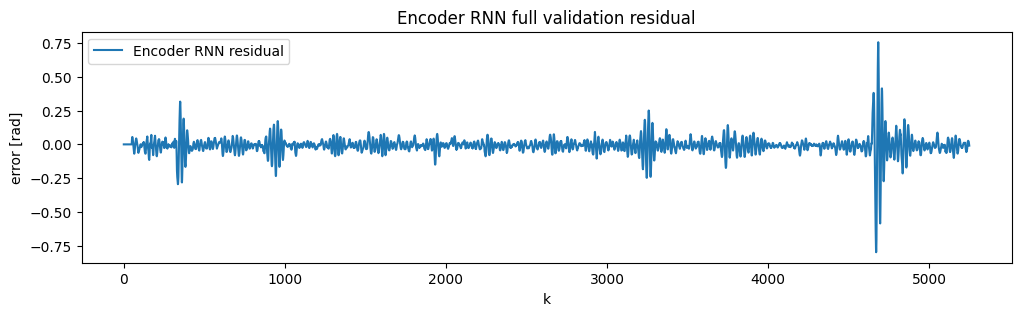

In [82]:
th_val_sim_encoder_rnn, th_val_true_encoder_rnn = simulate_encoder_rnn_full(
    model_encoder_rnn,
    u_val_n,
    th_val_n,
    n_encode,
    th_mean,
    th_std
)

skip = n_encode

rms_encoder_rnn = np.sqrt(
    np.mean((th_val_sim_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
)

rms_deg_encoder_rnn = rms_encoder_rnn / (2*np.pi) * 360
nrms_encoder_rnn = rms_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

print("Encoder RNN full validation simulation RMS:", rms_encoder_rnn, "rad")
print("Encoder RNN full validation simulation RMS:", rms_deg_encoder_rnn, "deg")
print("Encoder RNN full validation simulation NRMS:", nrms_encoder_rnn * 100, "%")

plt.figure(figsize=(12,4))
plt.plot(th_val_true_encoder_rnn, label="measured validation")
plt.plot(th_val_sim_encoder_rnn, label="Encoder RNN full simulation")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Encoder RNN full validation simulation")
plt.legend()
plt.show()

plt.figure(figsize=(12,3))
plt.plot(th_val_sim_encoder_rnn - th_val_true_encoder_rnn, label="Encoder RNN residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Encoder RNN full validation residual")
plt.legend()
plt.show()

## RNN tuning summary

As a recurrent neural-network baseline, a simple RNN was first trained using the structure from the exercise set. In this model, the hidden state was initialized to zero at the beginning of each sequence. The simple RNN achieved a full validation simulation RMSE of 0.1436 rad. This was better than the linear benchmark, but still significantly worse than the NOE model. The main limitation is that the zero initial hidden state does not contain information about the actual initial state of the system.

To improve this, an encoder RNN was tested. In this architecture, the initial hidden state is not fixed to zero, but is estimated from a past input-output history:


h_0 = encoder(u_{\text{past}}, y_{\text{past}})


This improved the full validation simulation RMSE from 0.1436 rad to 0.0909 rad for \(n_{encode}=20\) and hidden size 15. This confirmed that estimating the initial hidden state from past data is important for recurrent models in system identification.

The encoder history length and hidden state dimension were then tuned. Increasing the encoder history from \(n_{encode}=20\) to \(n_{encode}=50\) improved the result further, because the encoder had more information about the recent system behavior. With \(n_{encode}=50\) and hidden size 15, the RMSE decreased to 0.0835 rad. Increasing the hidden size to 30 with the same encoder history gave the best RNN result, with RMSE 0.0772 rad, corresponding to 4.42 degrees and NRMS 15.63%.

Additional experiments showed that further increasing the number of epochs from 50 to 100 did not improve the full validation simulation performance. Although the training loss continued to decrease, the full validation RMSE increased to 0.1039 rad, indicating overfitting or unstable long-horizon recurrent behavior. A larger encoder history of \(n_{encode}=100\) also worsened the performance, giving RMSE 0.2045 rad. This suggests that too large an encoder input dimension can make the initial state estimation problem harder for this relatively simple encoder network.

Overall, the encoder RNN clearly improved over the simple RNN, showing that hidden-state initialization is important. However, the best RNN result remained worse than the final NOE model. This indicates that, for this dataset and this simple RNN architecture, the explicit delayed-output structure of the NOE model was more effective than the learned hidden-state representation of the RNN.

## Encoder RNN one-step-ahead prediction

The best encoder RNN model was also evaluated in one-step-ahead prediction mode. For each validation time step, the encoder used the measured past input-output history to estimate the initial hidden state, and the RNN then predicted only the next output sample. This is easier than full free-run simulation, because the model is re-initialized from measured past data at every time step and prediction errors do not accumulate over the full validation trajectory.

In [83]:
final_encoder_rnn = model_encoder_rnn   
final_n_encode = 50                     

In [84]:
def one_step_prediction_encoder_rnn(model, u_seq, y_seq, n_encode, th_mean, th_std):
    """
    One-step-ahead prediction for the encoder RNN.

    At each time step, the encoder uses measured past input-output data
    to initialize the hidden state, and then predicts only the next output.
    """

    model.eval()

    y_pred_n = []

    # Copy first n_encode samples only to keep the same signal length
    for i in range(n_encode):
        y_pred_n.append(y_seq[i])

    with torch.no_grad():
        for k in range(n_encode, len(u_seq)):
            u_hist = u_seq[k-n_encode:k]
            y_hist = y_seq[k-n_encode:k]

            hist = np.concatenate((u_hist, y_hist))[None, :]
            u_now = u_seq[k:k+1][None, :]

            hist_t = torch.tensor(hist, dtype=torch.float64)
            u_now_t = torch.tensor(u_now, dtype=torch.float64)

            y_now_pred = model(inputs=u_now_t, hist=hist_t).numpy()[0, 0]

            y_pred_n.append(y_now_pred)

    y_pred_n = np.array(y_pred_n)

    y_pred = y_pred_n * th_std + th_mean
    y_true = y_seq * th_std + th_mean

    return y_pred, y_true

In [85]:
th_val_pred_encoder_rnn, th_val_true_encoder_rnn = one_step_prediction_encoder_rnn(
    final_encoder_rnn,
    u_val_n,
    th_val_n,
    final_n_encode,
    th_mean,
    th_std
)

skip = final_n_encode

rms_pred_encoder_rnn = np.sqrt(
    np.mean((th_val_pred_encoder_rnn[skip:] - th_val_true_encoder_rnn[skip:])**2)
)

rms_deg_pred_encoder_rnn = rms_pred_encoder_rnn / (2*np.pi) * 360
nrms_pred_encoder_rnn = rms_pred_encoder_rnn / np.std(th_val_true_encoder_rnn[skip:])

print("Encoder RNN one-step prediction RMS:", rms_pred_encoder_rnn, "rad")
print("Encoder RNN one-step prediction RMS:", rms_deg_pred_encoder_rnn, "deg")
print("Encoder RNN one-step prediction NRMS:", nrms_pred_encoder_rnn * 100, "%")

Encoder RNN one-step prediction RMS: 0.03073686210985488 rad
Encoder RNN one-step prediction RMS: 1.7610924743702594 deg
Encoder RNN one-step prediction NRMS: 6.222951971811259 %


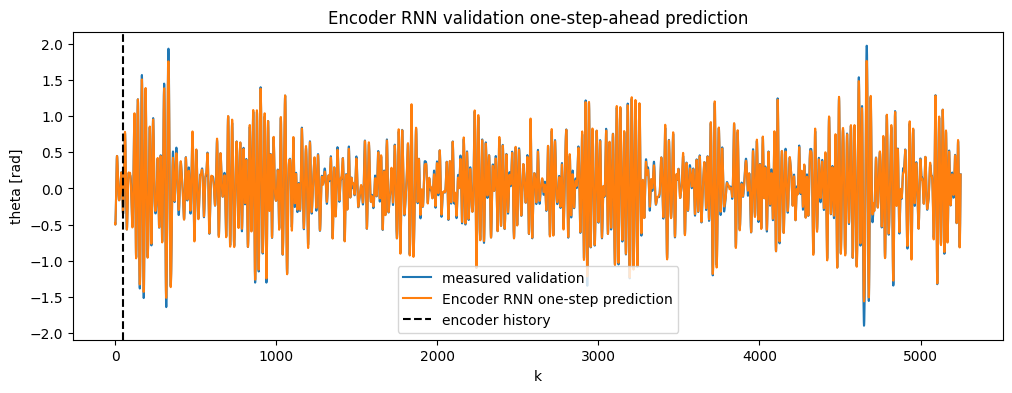

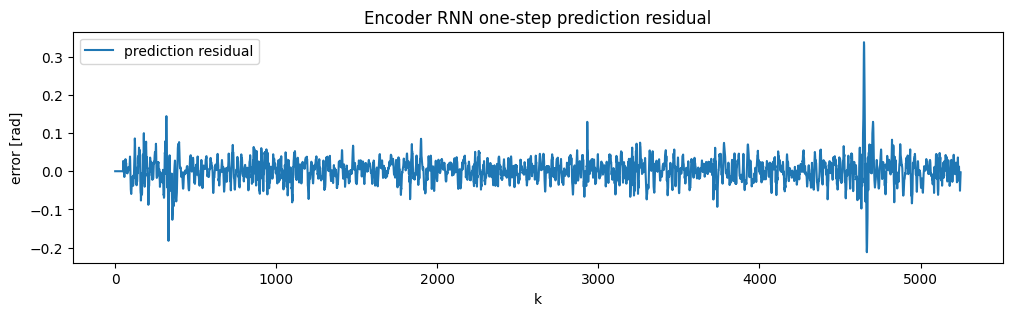

In [86]:
plt.figure(figsize=(12, 4))
plt.plot(th_val_true_encoder_rnn, label="measured validation")
plt.plot(th_val_pred_encoder_rnn, label="Encoder RNN one-step prediction")
plt.axvline(skip, color="black", linestyle="--", label="encoder history")
plt.xlabel("k")
plt.ylabel("theta [rad]")
plt.title("Encoder RNN validation one-step-ahead prediction")
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(th_val_pred_encoder_rnn - th_val_true_encoder_rnn, label="prediction residual")
plt.xlabel("k")
plt.ylabel("error [rad]")
plt.title("Encoder RNN one-step prediction residual")
plt.legend()
plt.show()